In [15]:
import os
import numpy as np
from time import time
from math import floor, ceil
from PIL import Image
import soundfile as    sf

# from sys import platform as sys_pf
# if sys_pf == 'darwin':
#     import matplotlib
#     matplotlib.use("TkAgg")
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20.0, 6.0)
plt.rc('axes.spines',top=False,bottom=False,left=False,right=False);
plt.rc('axes',facecolor=(1,1,1,0),edgecolor=(1,1,1,0));
plt.rc(('xtick','ytick'),color=(1,1,1,0));

import cv2

from scipy import signal
from scipy.io import wavfile
from skimage import exposure, measure

In [16]:
def bradley_roth(image, s=None, t=None):
    # -- from somewhere
    img = np.array(image).astype(np.float)

    # -- default window size is round(width/8)
    if s is None:
        s = np.round(img.shape[1]/8)

    # -- default threshold is 15% of the total area in the window
    if t is None:
        t = 15.0

    # -- integral image
    intImage = np.cumsum(np.cumsum(img, axis=1), axis=0)

    # -- define grid of points
    (rows, cols) = img.shape[:2]
    (X, Y)       = np.meshgrid(np.arange(cols), np.arange(rows))

    # -- make into 1D grid of coordinates for easier access
    X = X.ravel()
    Y = Y.ravel()

    # -- ensures is even so that we are able to index the image properly
    s = s + np.mod(s, 2)

    # -- access the four corners of each neighborhood area
    x1 = X - s/2
    x2 = X + s/2
    y1 = Y - s/2
    y2 = Y + s/2

    # -- assert no coordinates are out of bounds
    x1[x1<0]     = 0
    x2[x2>=cols] = cols-1
    y1[y1<0]     = 0
    y2[y2>=rows] = rows-1

    # -- assert coordinates are integers
    x1 = x1.astype(np.int)
    x2 = x2.astype(np.int)
    y1 = y1.astype(np.int)
    y2 = y2.astype(np.int)

    # -- count how many pixels are in each neighborhood
    count = (x2 - x1) * (y2 - y1)

    # -- compute the row and column coordinates to access each corner of the neighborhood for the integral image
    f1_x           = x2
    f1_y           = y2
    f2_x           = x2
    f2_y           = y1 - 1
    f2_y[f2_y < 0] = 0
    f3_x           = x1-1
    f3_x[f3_x < 0] = 0
    f3_y           = y2
    f4_x           = f3_x
    f4_y           = f2_y

    # -- compute areas of each window
    sums = intImage[f1_y, f1_x] - intImage[f2_y, f2_x] - intImage[f3_y, f3_x] + intImage[f4_y, f4_x]

    # -- compute thresholded image and reshape into a 2D grid
    out  = np.zeros(rows*cols, dtype=np.bool)
    out[img.ravel()*count <= sums*(100.0 - t)/100.0] = True

    # -- convert back to uint8
    out  = np.reshape(out, (rows, cols)).astype(np.uint8)

    return out

def imshow_components(labels):
    # Map component labels to hue val
    label_hue = np.uint8(179*labels/np.max(labels))
    blank_ch = 255*np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])

    # cvt to BGR for display
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)

    # set bg label to black
    labeled_img[label_hue==0] = 0

    plt.imshow(labeled_img)
    plt.show()

In [17]:
# file_path = '/Users/gustavo/Documents/git/ahof_vocalmat/audios/audio_example.wav'
file_path = '/Users/gustavo/Documents/git/vocalpy/audios/1303_Agrp-Trpv1_1st.WAV'
# file_path = '/Users/gustavo/Downloads/1303_Agrp-Trpv1_1st_48.wav'
print("selected file: {}".format(file_path))

samples, sample_rate    = sf.read(file_path)

# 59 120
sample_range = samples[ceil(58 * sample_rate):120*sample_rate]

fs                = sample_rate
window            = signal.get_window('hamming', 256)
noverlap          = 128
nfft              = 1024
sample_range_secs = sample_range.shape[0] / sample_rate

# -- compute spectrogram
f, t, Pxx = signal.spectrogram(sample_range, fs=fs,
                                             window=window,
                                             noverlap=noverlap,
                                             nfft=nfft,
                                             mode='psd')

# -- apply frequency cutoff
frequency_cutoff = 45000
Pxx = Pxx[(f>frequency_cutoff)]
f   = f[(f>frequency_cutoff)]

time_res         = sample_range_secs/t.shape[0]
freq_res         = (np.max(f) - frequency_cutoff) / f.shape[0]

selected file: /Users/gustavo/Documents/git/vocalpy/audios/1303_Agrp-Trpv1_1st.WAV


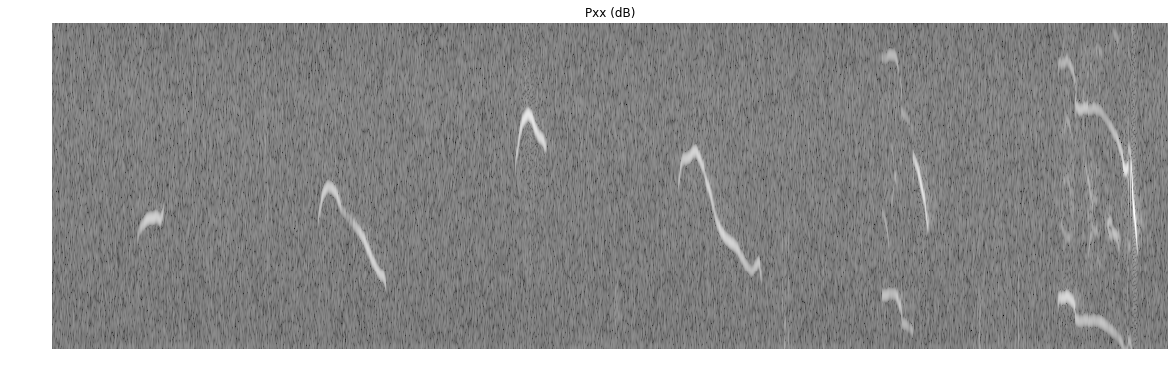

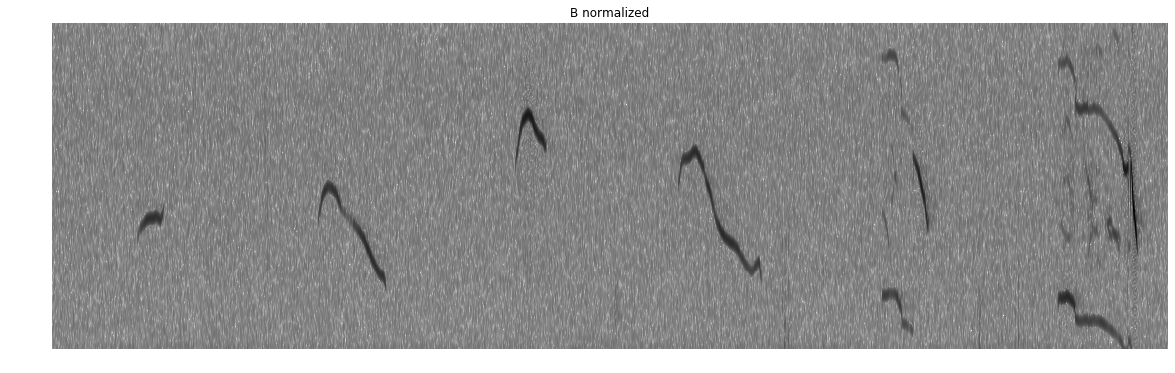

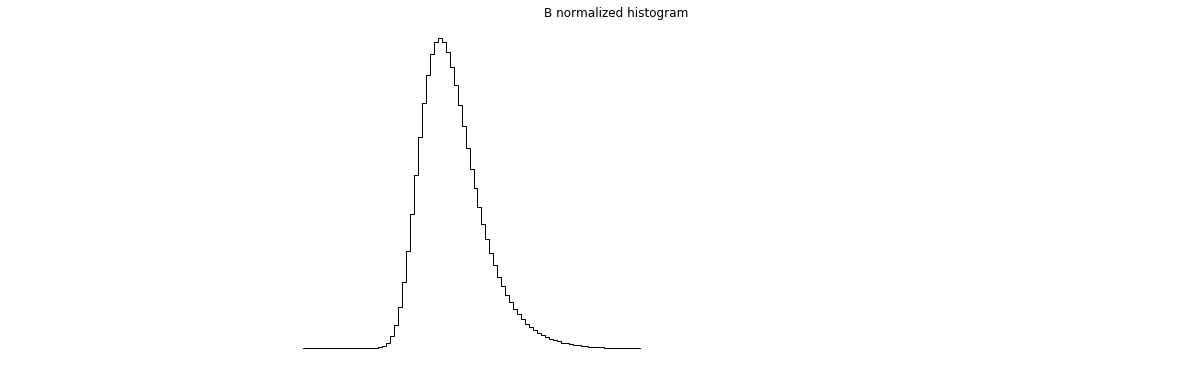

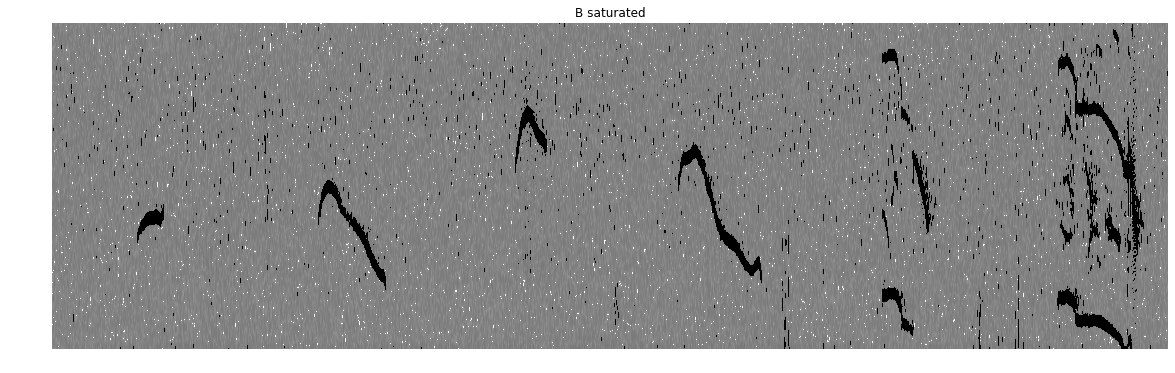

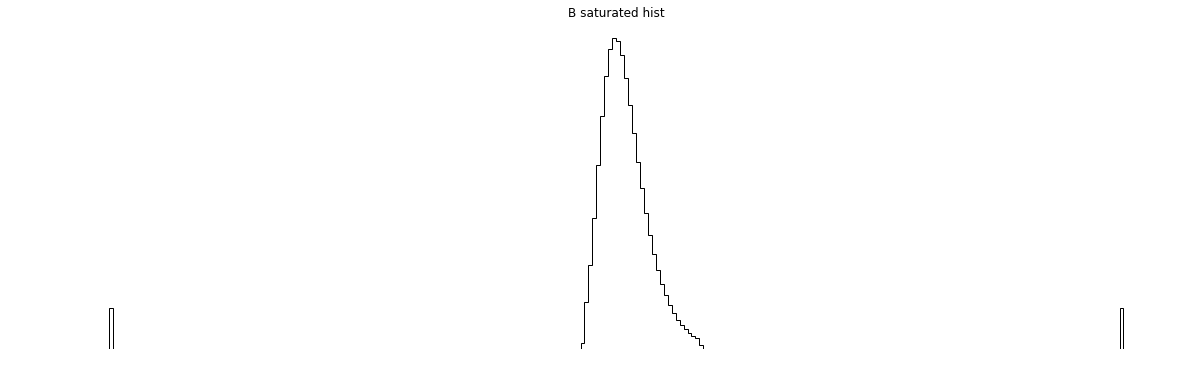

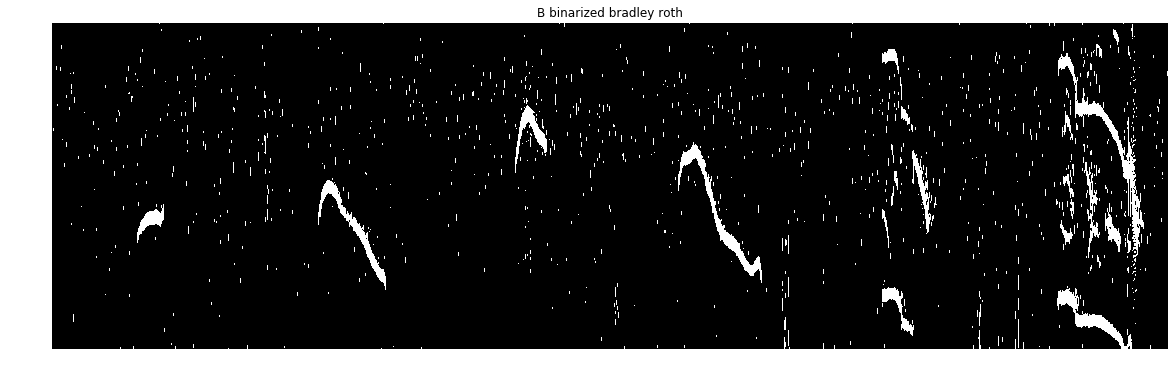

In [18]:
args = True
# -- convert to dB
Pxx = 10*np.log10(Pxx)
if args:
    plt.pcolormesh(t[19000:21000], f, Pxx[:,19000:21000], cmap='gray')
    plt.title('Pxx (dB)')
    plt.show()

# -- normalize data
# B = Pxx
# Bmax = np.max(B)
# Bmin = np.min(B)
# B    = (B - Bmin) / (Bmax - Bmin)
B = np.abs(Pxx)
B = B/np.max(B)
if args:
    plt.pcolormesh(t[19000:21000], f, B[:,19000:21000], cmap='gray')
    plt.title('B normalized')
    plt.show()
    plt.hist(B.ravel(), bins=256, histtype='step', color='black')
    plt.title('B normalized histogram')
    plt.show()

# -- contrast adjustment
p1, p99 = np.percentile(B, (1, 99))
B[B<p1] = 0
B[B>p99]= 1
if args:
    plt.pcolormesh(t[19000:21000], f, B[:,19000:21000], cmap='gray')
    plt.title('B saturated')
    plt.show()
    plt.hist(B.ravel(), bins=256, histtype='step', color='black')
    plt.title('B saturated hist')
    plt.show()

# -- binarize spectrogram
B = bradley_roth(B, t=20)
# B = bradley_roth(np.interp(B, (0,255), (0,1)), t=20)
# B = ii8.max - B
if args:
    plt.pcolormesh(t[19000:21000], f, B[:,19000:21000], cmap='gray')
    plt.title('B binarized bradley roth')
    plt.show()

In [19]:
import scipy

new_img = scipy.ndimage.median_filter(B, size=(3,3))
# plt.imshow(new_img, cmap='gray')
# plt.show()

In [20]:
B = new_img

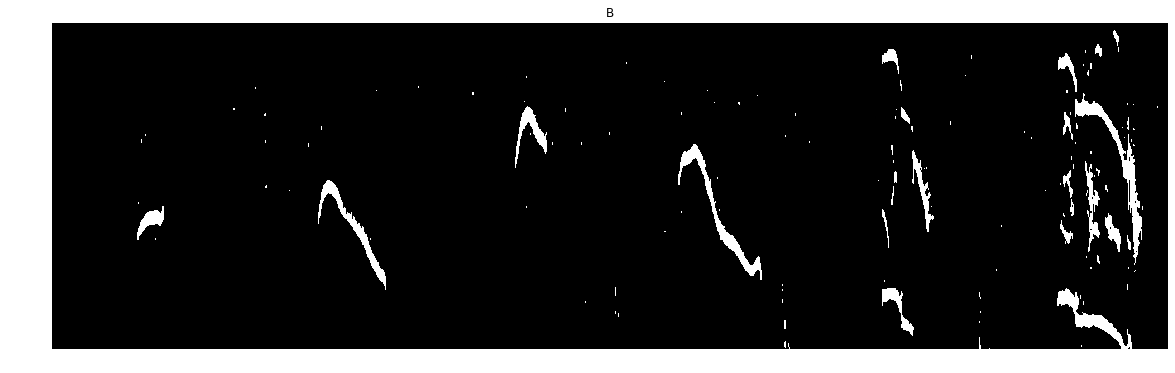

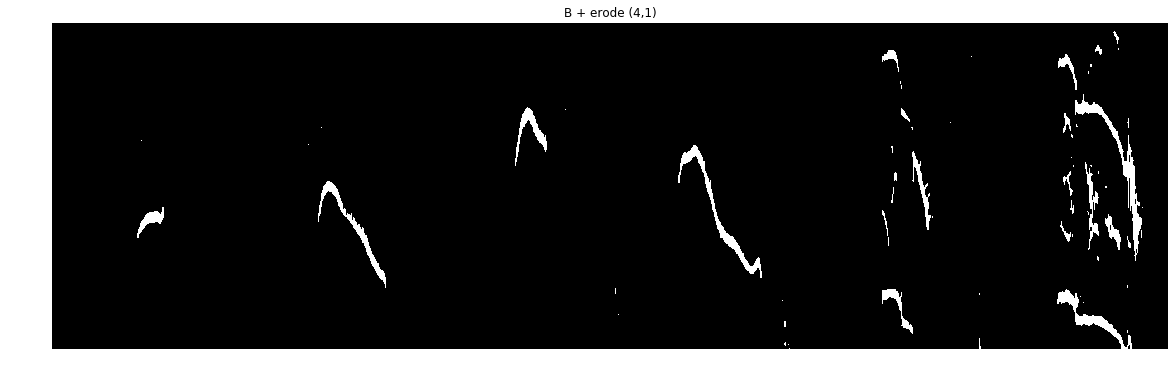

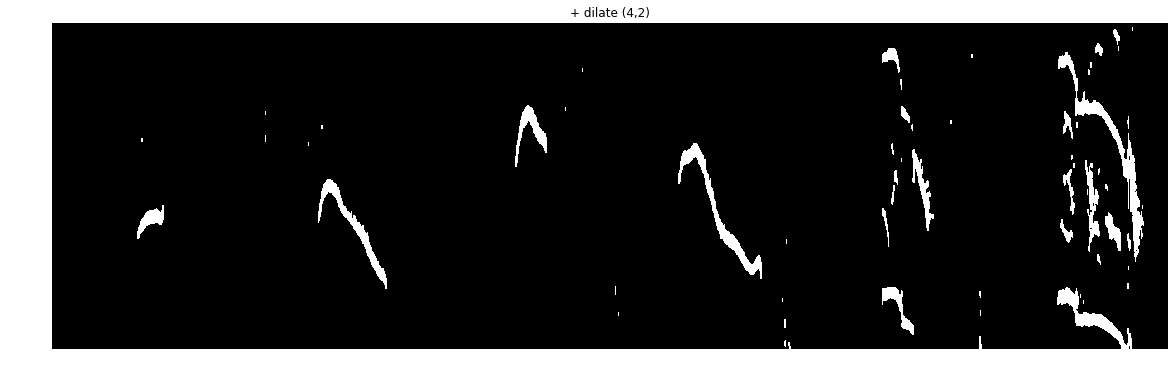

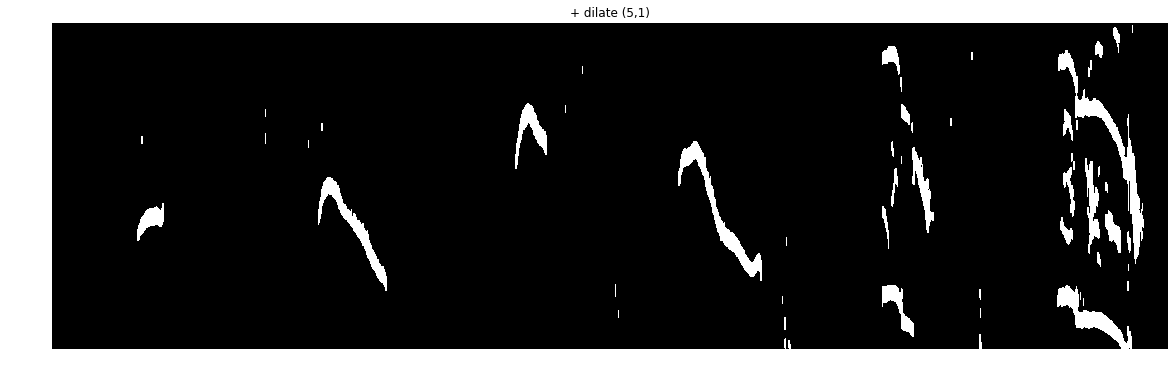

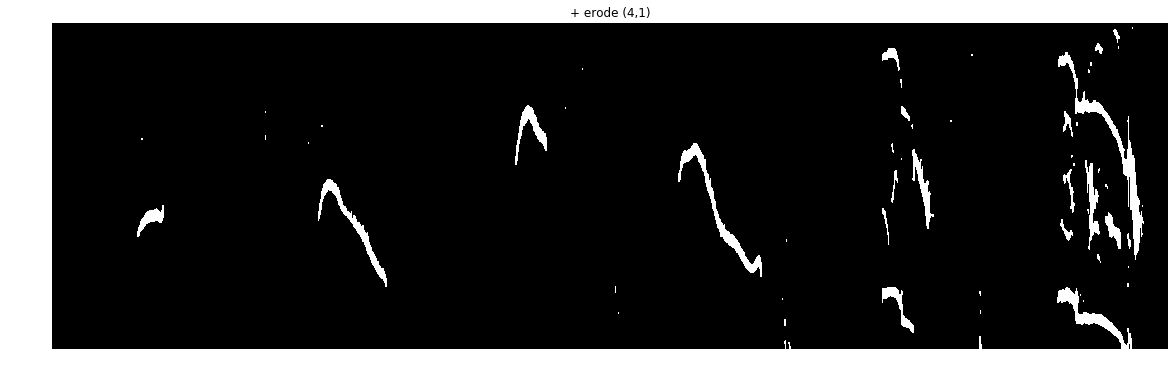

In [21]:
# -- kernels for morphological operations
kernel_rect  = np.ones((4,2), np.uint8)
kernel_line1 = np.ones((4,1), np.uint8)
kernel_line2 = np.ones((5,1), np.uint8)

# -- morphological operations
erode11  = cv2.erode(B, kernel_line1, iterations=1)
dilate12 = cv2.dilate(erode11, kernel_rect, iterations=1)
dilate13 = cv2.dilate(dilate12, kernel_line2, iterations=1)
erode14  = cv2.erode(dilate13, kernel_line1, iterations=2)

if args:
    plt.pcolormesh(t[19000:21000], f, B[:,19000:21000], cmap='gray')
    plt.title('B')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, erode11[:,19000:21000], cmap='gray')
    plt.title('B + erode (4,1)')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, dilate12[:,19000:21000], cmap='gray')
    plt.title('+ dilate (4,2)')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, dilate13[:,19000:21000], cmap='gray')
    plt.title('+ dilate (5,1)')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, erode14[:,19000:21000], cmap='gray')
    plt.title('+ erode (4,1)')
    plt.show()



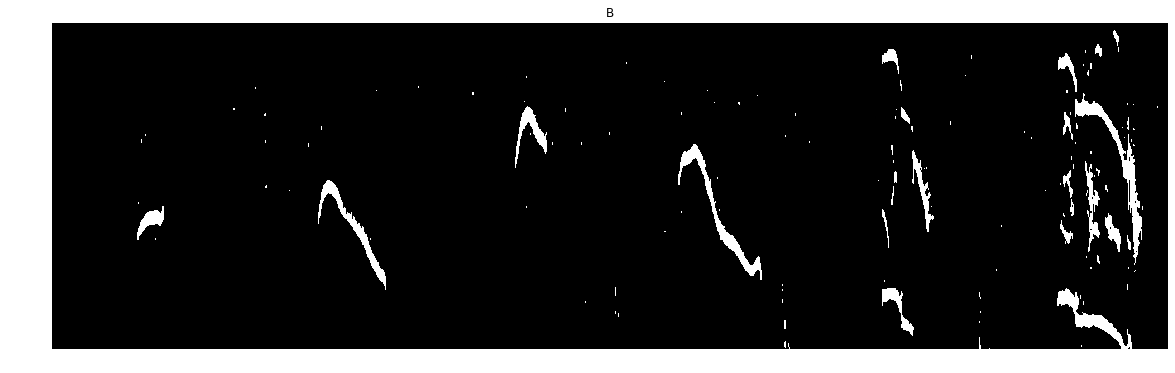

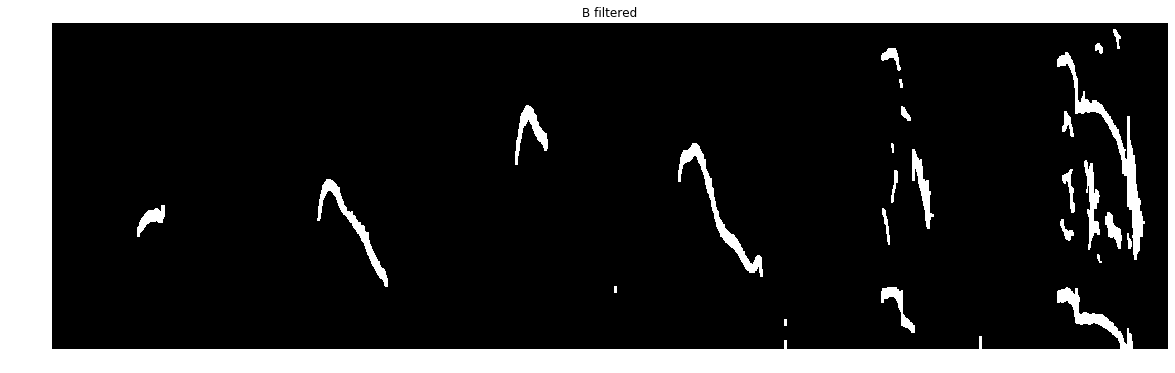

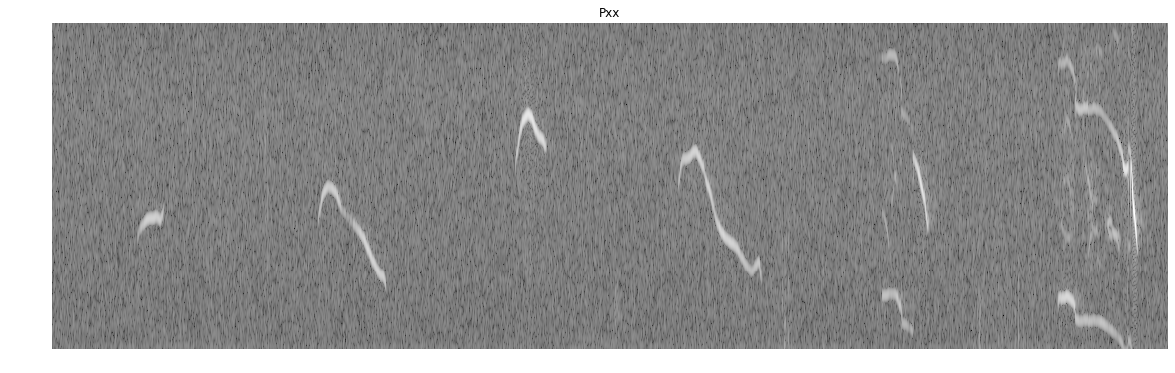

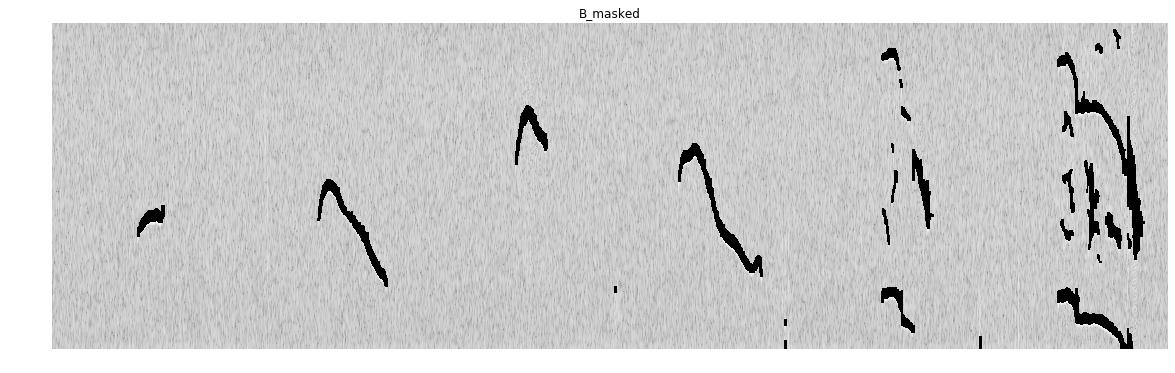

In [22]:
timeAConnectedComponents = time()
connectivity = 4
num_cc, output, stats, centroids = cv2.connectedComponentsWithStats(erode14, connectivity, cv2.CV_32S)

# -- remove background stats
num_cc = num_cc - 1
areas  = stats[1:,4]
# nr     = np.arange(num_cc)
# ranked = sorted(zip(areas,nr))

# -- filtered connected components placeholder
grain = np.zeros((output.shape))

# -- threshold connected components by minimum area
min_area = 20
for i in range(0, num_cc):
    if areas[i] >= min_area:
        grain[output == i + 1] = 255
timeBConnectedComponents = time()

# -- one more opening to make sure segmentation covers *at least* the real area
grain        = grain.astype(np.uint8)
kernel_cross = np.array([[0, 1, 0],
                         [1, 1, 1],
                         [0, 1, 0]], dtype=np.uint8)
kernel_line3 = np.ones((1,3), dtype=np.uint8)
grain        = cv2.dilate(grain, kernel_line3, iterations=1)

# -- rescale to save spectrograms in 8bit grayscale
dtype      = np.uint8
Pxx_scaled = exposure.rescale_intensity(Pxx, in_range='image', out_range=dtype)
if args:
    plt.pcolormesh(t[19000:21000], f, B[:,19000:21000], cmap='gray')
    # plt.pcolormesh(t, f, B, cmap='gray')
    plt.title('B')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, grain[:,19000:21000], cmap='gray')
    # plt.pcolormesh(t, f, grain, cmap='gray')
    plt.title('B filtered')
    plt.show()
    # -- get spectrogram area using the segmentation mask
    B_masked = Pxx_scaled * (((255 - grain) > 0) * 1)
    plt.pcolormesh(t[19000:21000], f, Pxx[:,19000:21000], cmap='gray')
    # plt.pcolormesh(t, f, Pxx, cmap='gray')
    plt.title('Pxx')
    plt.show()
    plt.pcolormesh(t[19000:21000], f, B_masked[:,19000:21000], cmap='gray')
    # plt.pcolormesh(t, f, B_masked, cmap='gray')
    plt.title('B_masked')
    plt.show()

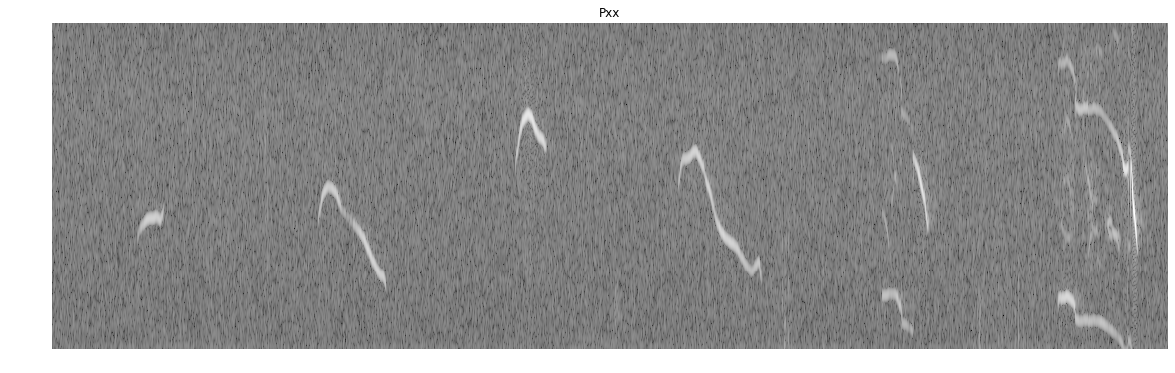

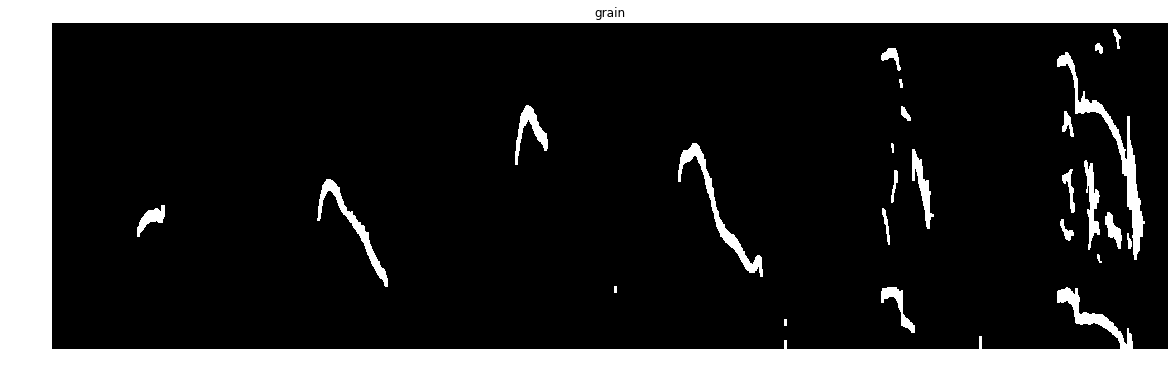

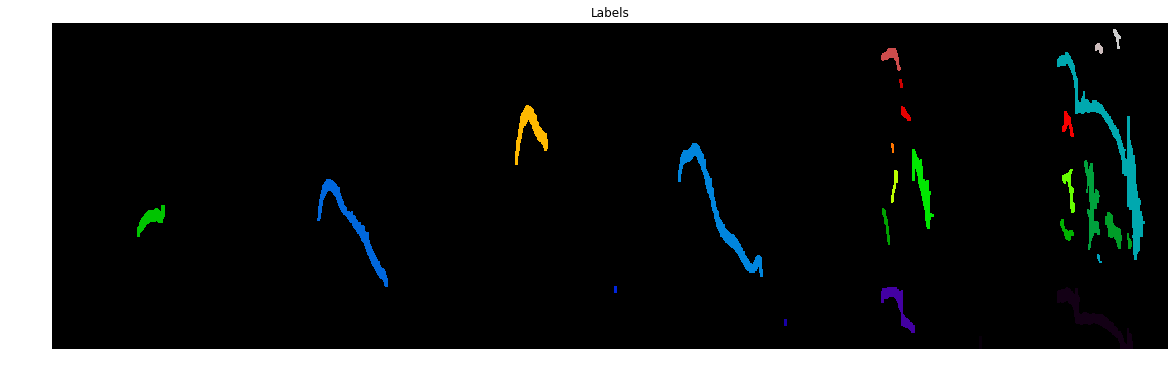

In [25]:
timeARegionProps = time()
labels = measure.label(grain, background=0)

props  = measure.regionprops(labels, intensity_image=Pxx, cache=True, coordinates='rc')
props  = sorted(props, key=lambda p: np.min(p.coords[:,1]), reverse=False)
timeBRegionProps = time()
if args:
#     plt.subplot(311)
    plt.pcolormesh(t[19000:21000], f, Pxx[:,19000:21000], cmap='gray')
    plt.title('Pxx')
    plt.show()
#     plt.subplot(312)
    plt.pcolormesh(t[19000:21000], f, grain[:,19000:21000], cmap='gray')
    plt.title('grain')
    plt.show()
#     plt.subplot(313)
    plt.pcolormesh(t[19000:21000], f, labels[:,19000:21000], cmap='nipy_spectral')
    plt.title('Labels')
    plt.show()

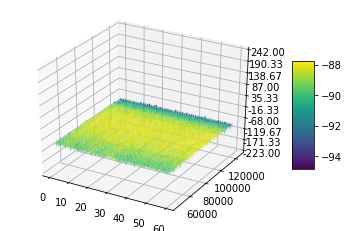

In [9]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
# %matplotlib qt 
fig = plt.figure()
ax = fig.gca(projection='3d')
X, Y = np.meshgrid(t[420:-375], f)
surf = ax.plot_surface(X, Y, Pxx[:,420:-375], cmap=cm.viridis, linewidth=0, antialiased=True)

ax.set_zlim(-223, 242)
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

In [ ]:

y0, x0 = props.centroid
orientation = props.orientation
x1 = x0 + math.cos(orientation) * 0.5 * props.major_axis_length
y1 = y0 - math.sin(orientation) * 0.5 * props.major_axis_length
x2 = x0 - math.sin(orientation) * 0.5 * props.minor_axis_length
y2 = y0 - math.cos(orientation) * 0.5 * props.minor_axis_length

ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
ax.plot(x0, y0, '.g', markersize=15)

minr, minc, maxr, maxc = props.bbox
bx = (minc, maxc, maxc, minc, minc)
by = (minr, minr, maxr, maxr, minr)
ax.plot(bx, by, '-b', linewidth=2.5)

In [24]:
from vocal import Vocal
from list_of_vocals import ListOfVocals
from recording import Recording

In [121]:
recording = np.load('/Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording.vocalpy', allow_pickle=True)
list_of_vocals = recording._list_of_vocals

Vocal:
 bin_number: 2 
 start: 60.015360196610516 
 end: 60.05120065536839 
 duration: 35.8404587578721 
 interval: 3983.706021804778 
 min_freq: 76219.51219512195 
 max_freq: 96219.51219512196 
 avg_freq: 85099.60413740264 
 bandwidth: 20000.000000000015 
 min_intensity: -138.5650328483693 
 max_intensity: -81.63937485084284 
 avg_intensity: -105.88309783568397 
 bg_intensity: -120.81804910385696 
 area: 1337 
 centroid: [164, 200] 
 orientation: None 



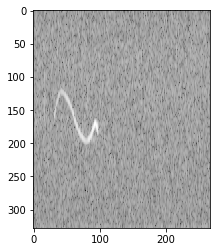

In [122]:
idx = 112
print(list_of_vocals.vocals_in_recording[idx])
plt.imshow(list_of_vocals.vocals_in_recording[idx].spectrogram, cmap='gray')

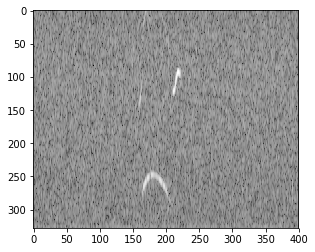

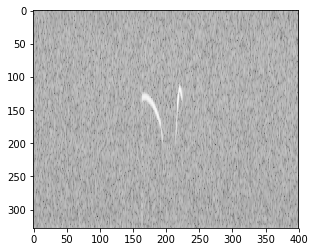

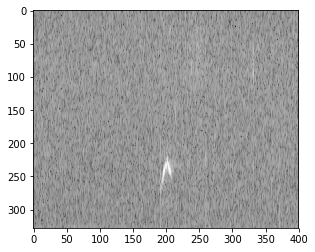

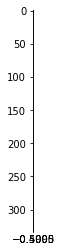

In [94]:
for i in range(109,113):
    plt.figure()
    plt.imshow(list_of_vocals.vocals_in_recording[i].spectrogram, cmap='gray')

In [76]:
list(list_of_vocals.vocals_in_recording).sort(key=lambda x: x.start, reverse=True)

Vocal:
 bin_number: 10 
 start: 599.7076442578465 
 end: 599.7296605396549 
 duration: 0.02201628180841908 
 interval: 17.408222825224584 
 min_freq: 49390.243902439026 
 max_freq: 104268.29268292684 
 avg_freq: 86734.01133738333 
 bandwidth: 54878.048780487814 
 min_intensity: -109.18720061622653 
 max_intensity: -65.03754909886793 
 avg_intensity: -74.77048484795688 
 bg_intensity: -87.2413468968571 
 area: 488 
 centroid: [200, 171.5] 
 orientation: None 

Vocal:
 bin_number: 10 
 start: 599.7465567559265 
 end: 599.7639649787517 
 duration: 17.408222825252164 
 interval: 16.89621627156157 
 min_freq: 70609.75609756098 
 max_freq: 92317.07317073172 
 avg_freq: 83679.58942119253 
 bandwidth: 21707.317073170736 
 min_intensity: -111.3260907326159 
 max_intensity: -40.35266590033271 
 avg_intensity: -70.42660630960675 
 bg_intensity: -87.2040873316953 
 area: 1257 
 centroid: [200, 159] 
 orientation: None 



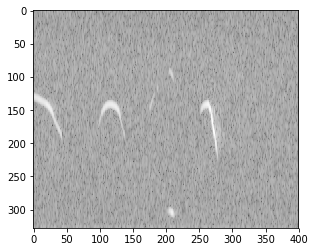

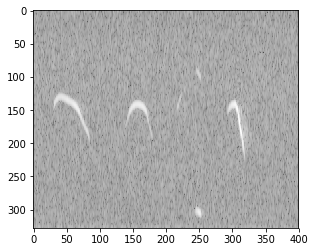

In [86]:
print(list_of_vocals.vocals_in_recording[1162])
print(list_of_vocals.vocals_in_recording[1163])
plt.imshow(list_of_vocals.vocals_in_recording[1162].spectrogram, cmap='gray')
plt.figure()
plt.imshow(list_of_vocals.vocals_in_recording[1163].spectrogram, cmap='gray')

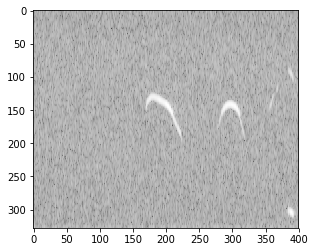

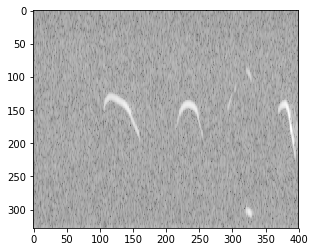

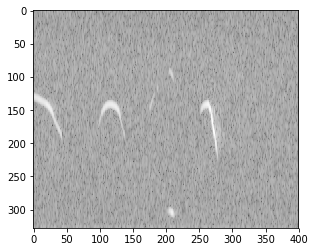

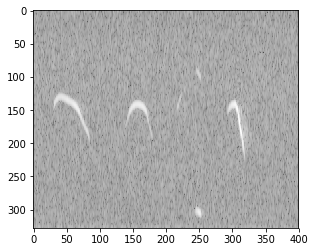

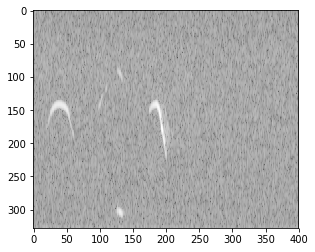

In [83]:
for i in range(1160,1165):
    plt.figure()
    plt.imshow(list_of_vocals.vocals_in_recording[i].spectrogram, cmap='gray')

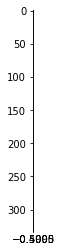

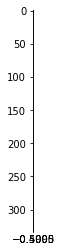

In [47]:
idx = 1168
vcl = list_of_vocals.vocals_in_recording[idx].spectrogram
plt.figure()
plt.imshow(vcl, cmap='gray')
plt.figure()
plt.imshow(list_of_vocals.vocals_in_recording[idx].mask, cmap='gray')

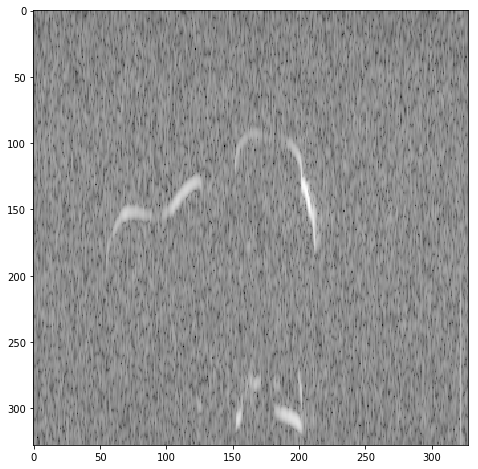

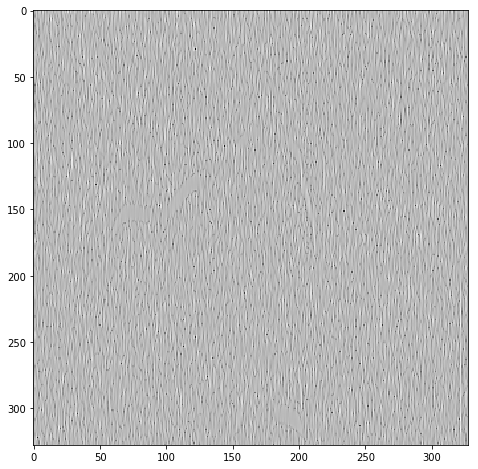

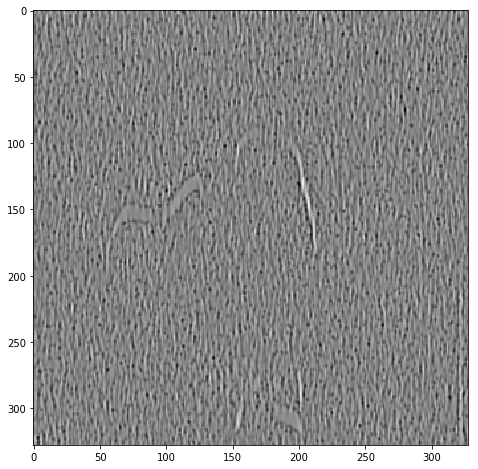

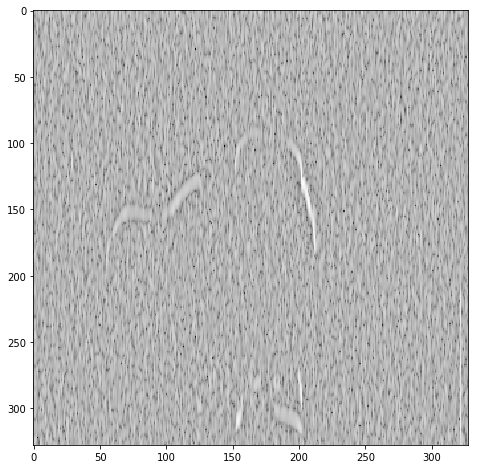

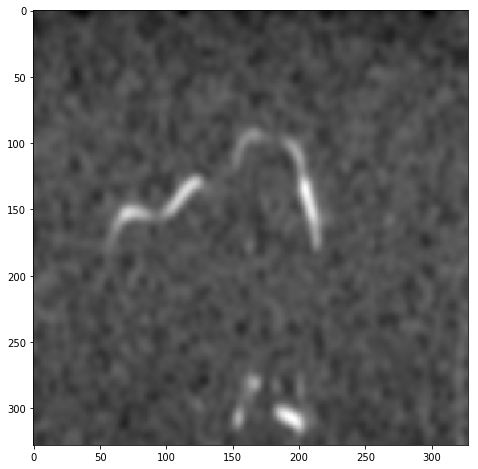

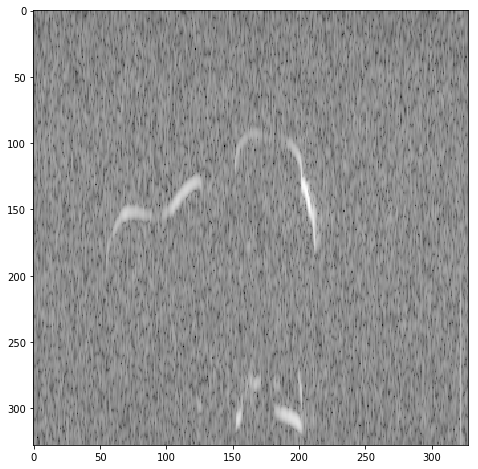

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from PIL import Image

# Load the data...
im = vcl
data = np.array(im, dtype=float)

plt.figure(figsize=(8,8))
plt.imshow(data ,cmap='gray')

# A very simple and very narrow highpass filter
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])
highpass_3x3 = ndimage.convolve(data, kernel)

plt.figure(figsize=(8,8))
plt.imshow(highpass_3x3, cmap='gray')

# A slightly "wider", but sill very simple highpass filter 
kernel = np.array([[-1, -1, -1, -1, -1],
                   [-1,  1,  2,  1, -1],
                   [-1,  2,  4,  2, -1],
                   [-1,  1,  2,  1, -1],
                   [-1, -1, -1, -1, -1]])
highpass_5x5 = ndimage.convolve(data, kernel)

plt.figure(figsize=(8,8))
plt.imshow(highpass_5x5, cmap='gray')

# Another way of making a highpass filter is to simply subtract a lowpass
# filtered image from the original. Here, we'll use a simple gaussian filter
# to "blur" (i.e. a lowpass filter) the original.
lowpass = ndimage.gaussian_filter(data, 3)
gauss_highpass = data - lowpass

plt.figure(figsize=(8,8))
plt.imshow(gauss_highpass, cmap='gray')

plt.figure(figsize=(8,8))
plt.imshow(lowpass, cmap='gray')

plt.figure(figsize=(8,8))
plt.imshow(lowpass + gauss_highpass, cmap='gray')